In [1]:
import numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
from tqdm import tqdm
import scipy.optimize as scp

In [2]:
def read_files_s(parameters):
    q=parameters["q"];
    L=parameters["L"];
    R=parameters["R"];
    D=parameters["D"];
    U=parameters["U"];
    nSteps=parameters["nSteps"];
    seed=parameters["seed"];
    heat=parameters["heat"];
    N = L * L;
    name = "./datasets/spin_samples/2DBlume{}_q{}_D{}_N{}_R{}_nSteps{}_run{}_U{}s.txt".format(
        "Heating" * heat, q, "{0:07.6f}".format(D), N, R, nSteps, seed, "{0:07.6f}".format(U))

    
    with open(name) as f:
        for line in f:
            parameters['spin_sample'] = line.split()
            break;

    return parameters

#def read_tuple_files_m(tpl):
#    if tpl[1]["heat"]:
#        return {
#            "cool": read_files_m(tpl[0]),
#            "heat": read_files_m(tpl[1])
#        }


In [34]:
D = 2.0
L = [x for x in [8, 12, 16, 20, 24, 32, 48, 64, 80, 96] if x == 8]

R = [32768, 131072]

cool, heat = [{
    "q": 3,
    "D": D,
    "L": l,
    "U": 0.0,
    #"R" : R,
    "nSteps" : 10,
    "seed" : 0,
    "heat": False
} for l in L], [{
    "q": 3,
    "D": D,
    "L": l,
    "U": 0.0,
    #"R" : R,
    "nSteps" : 10,
    "seed" : 0,
    "heat": True
} for l in L]
print('D={}'.format(D))

parameters = []
for c, h in zip(cool, heat):
    #try:
    c['R'] = R[1]
    h['R'] = R[1]
    #parameters.append(read_tuple_files_m((c, h)))
    parameters.append(read_files_s(c))
    #except:
    #    pass
        
#for i, x in enumerate(tqdm(parameters)):
#parameters[i]["stitched"] = stitch(x["heat"], x["cool"])
#print('L in {}'.format(", ".join([str(x["stitched"]["L"]) for x in parameters]) ))
#print('R in {}'.format(", ".join([str(x["heat"]["R"]) for x in parameters]) ))


D=2.0


In [36]:
data = list( map(lambda x: int(x), parameters[0]['spin_sample']) )

In [38]:
[data[i:i + 64] for i in range(0, len(data), 64)]


[[0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1],
 [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,

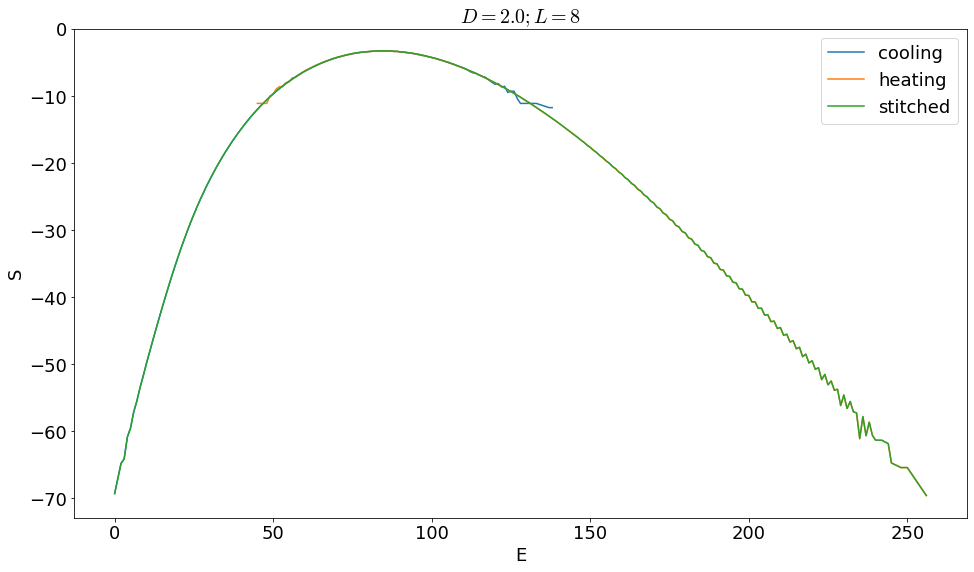

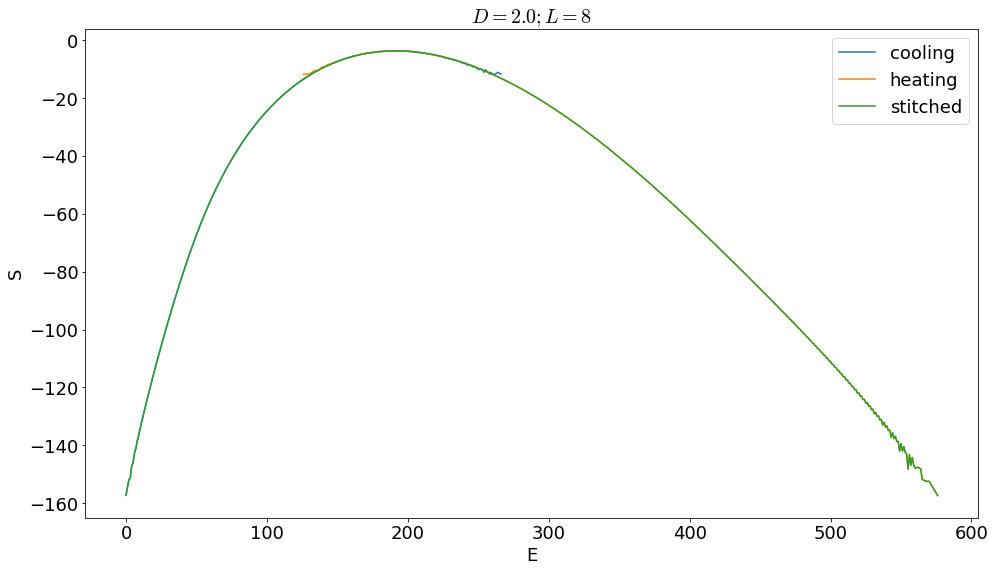

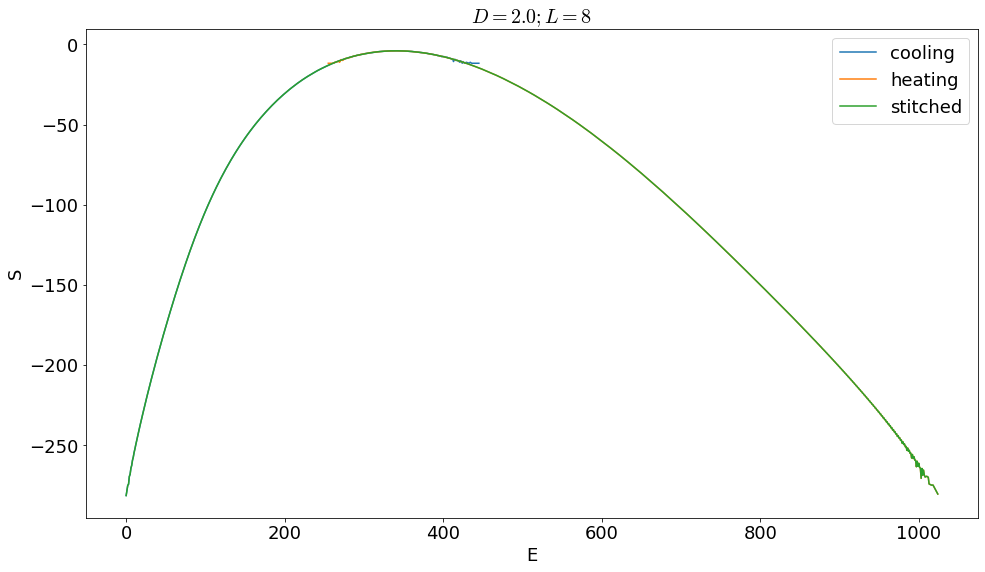

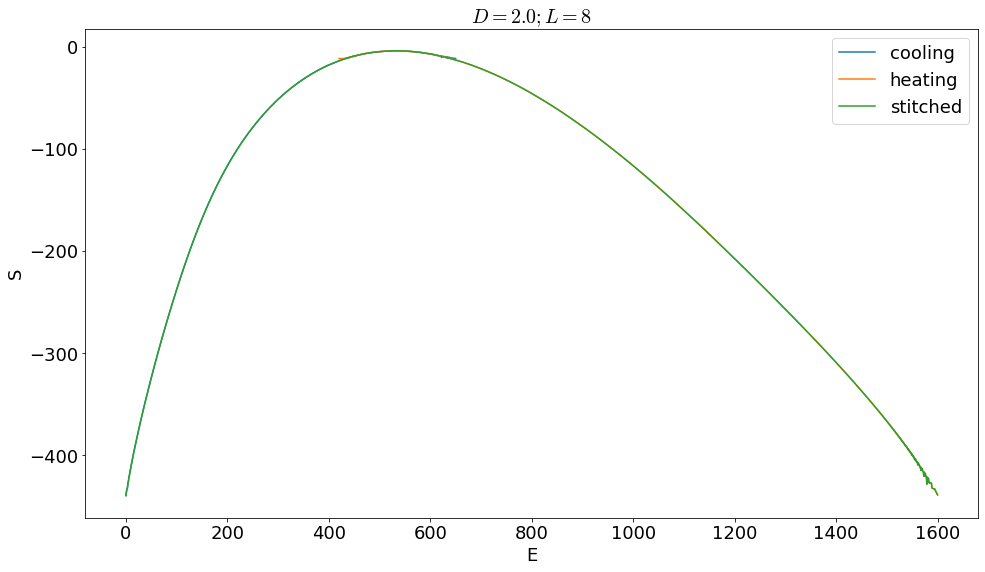

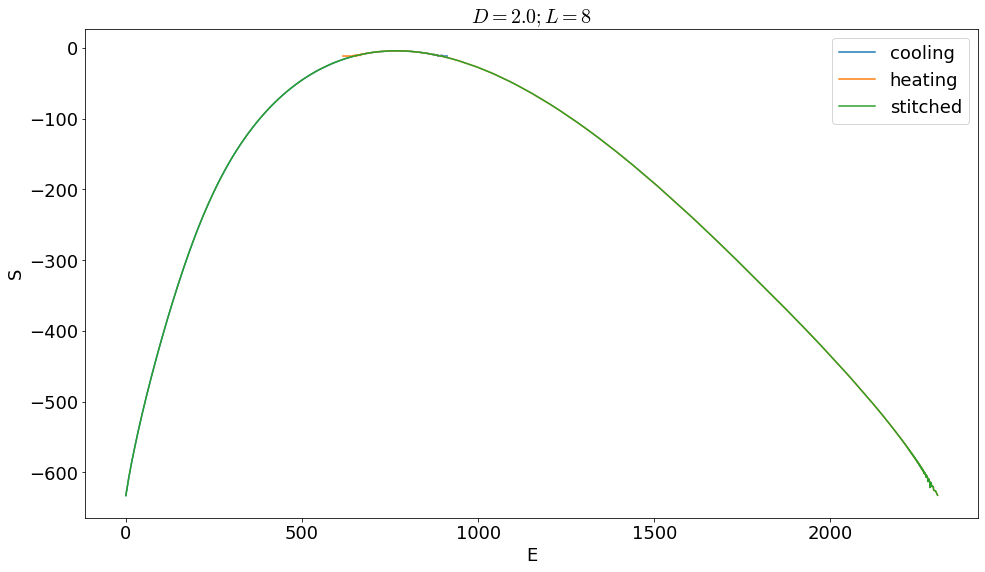

In [30]:
for x in parameters:
    plt.figure(figsize=(16, 9))
    plt.rcParams["mathtext.fontset"] = "cm"
    plt.rcParams.update({'font.size': 18})

    cool = x['cool']
    heat = x['heat']
    stitched = x['stitched']

    plt.plot([e for e in cool['S']], [m for e, m in cool['S'].items()], label='cooling')
    plt.plot([e for e in heat['S']], [m for e, m in heat['S'].items()], label='heating')

    plt.plot([e for e in stitched['S']], [m + 0.01 for e, m in stitched['S'].items()], label='stitched')
    plt.xlabel('E')
    plt.ylabel('S')
    plt.legend()
    plt.title("$D={}; L={}$".format(parameters[0]['cool']['D'], parameters[0]['cool']['L']), fontsize=20)
    plt.show()

In [12]:
def f(m, T, D):
    return 2 * np.exp(-D / T) * np.sinh(4 * m / T) / (1 + 2 * np.exp(-D / T) * np.cosh(4 * m / T)) - m

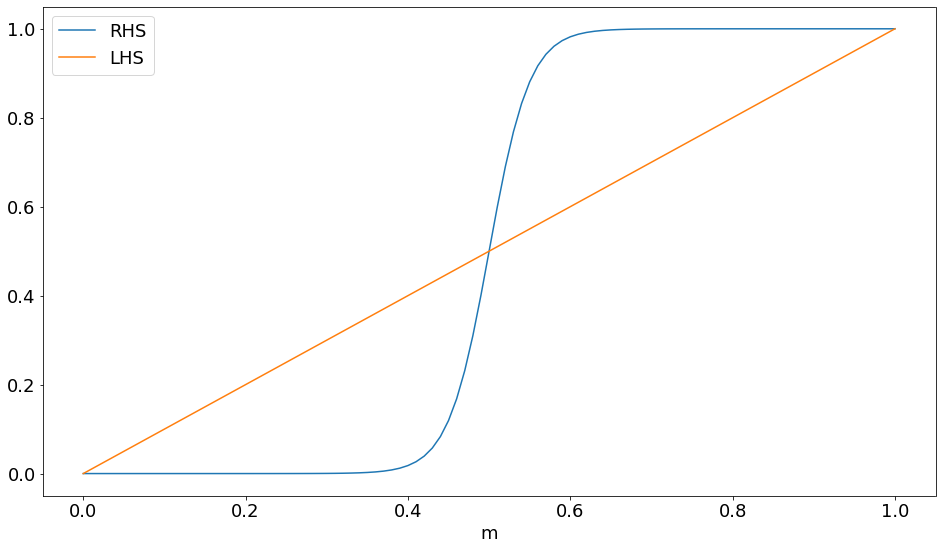

'The solution converged.'

In [89]:
plt.figure(figsize=(16, 9))
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams.update({'font.size': 18})

x = np.linspace(0, 1, 101)
T = 0.1
D = 2.0

plt.plot(x, [m + f(m, T, D) for m in x], label='RHS')
plt.plot(x, x, label='LHS')

plt.xlabel('m')
#plt.ylabel('m')
plt.legend()
#plt.title("$D={}; L={}$".format(parameters[0]['cool']['D'], parameters[0]['cool']['L']), fontsize=20)
plt.show()

scp.fsolve(f, 1.0, args=(T, D), full_output=True)[3]

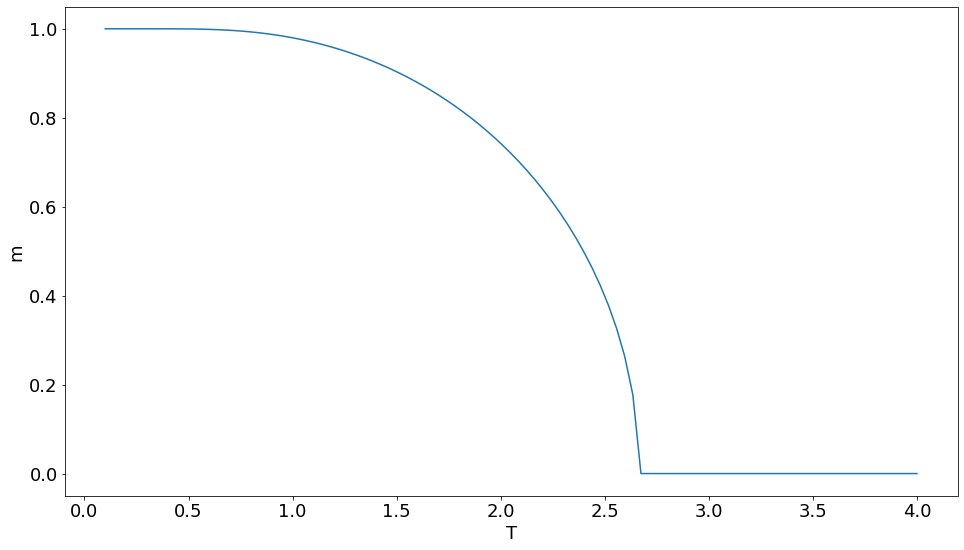

In [150]:
plt.figure(figsize=(16, 9))
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams.update({'font.size': 18})

D = 0.0
T = np.linspace(0.1, 4.0, 101)
tmp = [scp.fsolve(f, 1.0, args=(t, D), full_output=True) for t in T]
M = [x[0][0] if x[3] == 'The solution converged.' else 0 for x in tmp]
plt.plot(T, M)

plt.ylabel('m')
plt.xlabel('T')

plt.show()

In [13]:
D = np.linspace(0.0, 4 * np.log(4)/3, 1001)
Crit = []

for d in tqdm(D):
    T = np.linspace(0.1, 4.0, 1001)
    tmp = [scp.fsolve(f, 1.0, args=(t, d), full_output=True) for t in T]
    M = [x[0][0] if x[3] == 'The solution converged.' else 0 for x in tmp]
    #print(T)
    #print(M)
    
    crit = (0, 0)
    for m, t in zip(reversed(M), reversed(T)):
        #print(t, m)
        if m > 0.01:
            crit = (t, m)
            break
    Crit.append(crit)


100%|██████████████████████████████████████████████████████████████████████████████| 1001/1001 [03:56<00:00,  4.23it/s]


In [14]:
D2 = np.linspace(4 * np.log(4)/3, 2, 1001)
Crit2 = []

for d in tqdm(D2):
    T = np.linspace(0.1, 4.0, 1001)
    tmp = [scp.fsolve(f, 1.0, args=(t, d), full_output=True) for t in T]
    M = [x[0][0] if x[3] == 'The solution converged.' else 0 for x in tmp]
    #print(T)
    #print(M)
    
    crit = (0, 0)
    for m, t in zip(reversed(M), reversed(T)):
        #print(t, m)
        if m > 0.01:
            crit = (t, m)
            break
    Crit2.append(crit)


100%|██████████████████████████████████████████████████████████████████████████████| 1001/1001 [07:07<00:00,  2.34it/s]


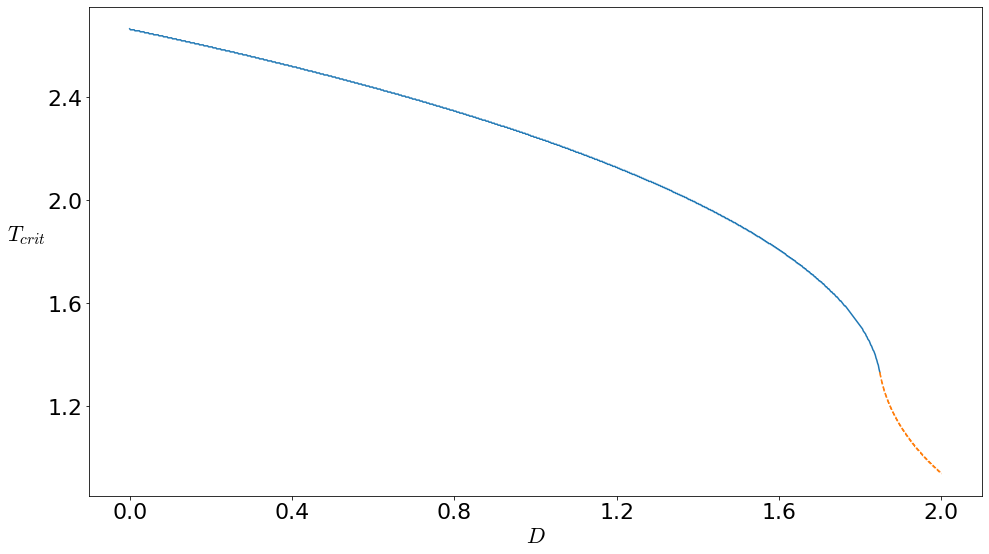

In [53]:
fig, ax = plt.subplots()
fig.set_size_inches(16, 9)

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams.update({'font.size': 22})

ax.yaxis.set_label_coords(-0.07, 0.51)


ax.xaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.4))

#plt.plot(T, M)
ax.plot(D, [x[0] for x in Crit], label='second-order line')
ax.plot(D2, [x[0] for x in Crit2], '--', label='first-order line')

ax.set_ylabel("$T_{crit}$", rotation=0, fontsize=22)
ax.set_xlabel("$D$", fontsize=22)

#plt.legend()
#plt.show()
plt.savefig('./images/MF_Phase_Diagram.png')


In [23]:
T_crit = {}
D_list = [0.0, 0.5, 1.0, 1.5, 1.6, 1.75, 1.87, 1.9, 1.91, 1.92, 1.93, 1.94, 1.95, 1.96,
                        1.961, 1.962, 1.963, 1.964, 1.965, 1.966, 1.967, 1.968, 1.969,
                        1.97, 1.971, 1.972, 1.973, 1.974, 1.975, 1.976, 1.977, 1.978, 1.979,
                        1.98, 1.99,
              ]
for DD in tqdm(D_list):

#D = 0.0
    T_crit[DD] = {}
    with open("./txt/T_crit_D{}.txt".format(DD), 'r') as fp:
        data = json.load(fp);
        for L in data:
            T = data[L]['T_crit']
            C = data[L]['C_crit']
            T_crit[DD][int(L)] = {'T_crit': float(T), 'C_crit': float(C)}

100%|████████████████████████████████████████████████████████████████████████████████| 35/35 [00:00<00:00, 5847.70it/s]


In [185]:
4 * np.log(4)/3

1.8483924814931874

In [2]:
dButera = {
    0: 1.69378,
    0.5: 1.5664,
    1.0: 1.3986,
    1.5: 1.1467,
    1.7027: 0.994,
    1.75: 0.950,
    1.87: 0.812,
    1.9: 0.766,
    1.92: 0.7289,
    1.9501: 0.656,
}
dBeale = {
    0: 1.695,
    0.5: 1.567,
    1.0: 1.398,
    1.5: 1.150,
    1.87: 0.8,
    1.92: 0.7,
    1.95: 0.65,
    1.962: 0.62,
    1.99: 0.55
}
dXALP98 = {
    0: 1.681,
    1.9: 0.764,
    1.9655: 0.609
}
dWLSCP06 = {
    0: 1.714,
    0.5: 1.584,
    1.0: 1.412,
    1.5: 1.155,
    1.87: 0.8,
    1.9: 0.755,
    1.92: 0.713,
    1.95: 0.651,
    1.962: 0.619,
    1.99: 0.555
}
dMR = {
    0: 1.694,
    0.5: 1.5686,
    1.0: 1.401,
    1.5: 1.155,
    1.6: 1.085,
    1.7: 1.006,
    1.75: 0.961,
    1.87: 0.8203,
    1.9: 0.7731,
    1.92: 0.7338,
    1.95: 0.6613,
    1.96: 0.6321,
    1.962: 0.6219,
    1.964: 0.6156,
    1.965: 0.6121,
    1.966: 0.6089,
    1.967: 0.6057,
    1.97: 0.601,
    1.98: 0.549,
    1.99: 0.5612,
    }
dZ17 = { # reverce!
    1.6: 0.375,
    1.5: 0.7101,
    1.4: 0.9909,
    1.398: 0.9958,
    1.3: 1.2242,
    1.2: 1.4167,
    1.1: 1.5750,
    1.0: 1.70258,
    0.9: 1.80280,
    0.8: 1.87879,
    0.7: 1.93296,
    0.65: 1.95273,
    0.6: 1.968174,
    0.5: 1.987889,
    0.4: 1.99683
}

NameError: name 'D' is not defined

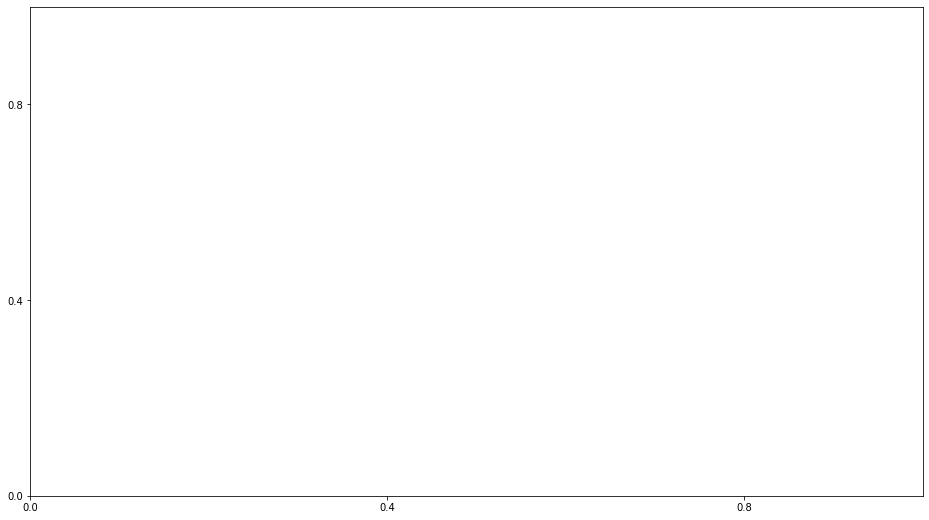

In [6]:
fig, ax = plt.subplots()
fig.set_size_inches(16, 9)

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams.update({'font.size': 22})

ax.yaxis.set_label_coords(-0.07, 0.51)

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.4))

#plt.plot(T, M)
ax.plot(D, [x[0] for x in Crit], label='MF II')
ax.plot(D2, [x[0] for x in Crit2], '--', label='MF I')


radius=600
plt.scatter([D for D, T in dBeale.items()], [T for D, T in dBeale.items()], label='Beale86',
         facecolors='none', edgecolors='darkblue', s=radius, marker='o')
plt.scatter([D for D, T in dXALP98.items()], [T for D, T in dXALP98.items()], label='XALP98',
         facecolors='none', edgecolors='black', s=radius, marker='v')
plt.scatter([D for D, T in dWLSCP06.items()], [T for D, T in dWLSCP06.items()], label='WL SCP06',
         facecolors='none', edgecolors='g', s=radius, marker='s')
plt.scatter([D for D, T in dButera.items()], [T for D, T in dButera.items()], label='Butera18',
         facecolors='none', edgecolors='r', s=radius, marker='D')
plt.scatter([D for D, T in dMR.items()], [T for D, T in dMR.items()], label='Machta-Rose',
         facecolors='none', edgecolors='violet', s=radius, marker='X')
plt.scatter([D for T, D in dZ17.items()], [T for T, D in dZ17.items()], label='Zierenberg-2017',
         facecolors='none', edgecolors='y', s=radius, marker='+')


#ax.set_xlim([0.0, 2.0])
ax.set_ylabel("$T_{crit}$", rotation=0, fontsize=22)
ax.set_xlabel("$D$", fontsize=22)
fig.tight_layout()

#plt.legend()
#plt.show()
plt.savefig('./images/MF_Phase_Diagram_2.png')


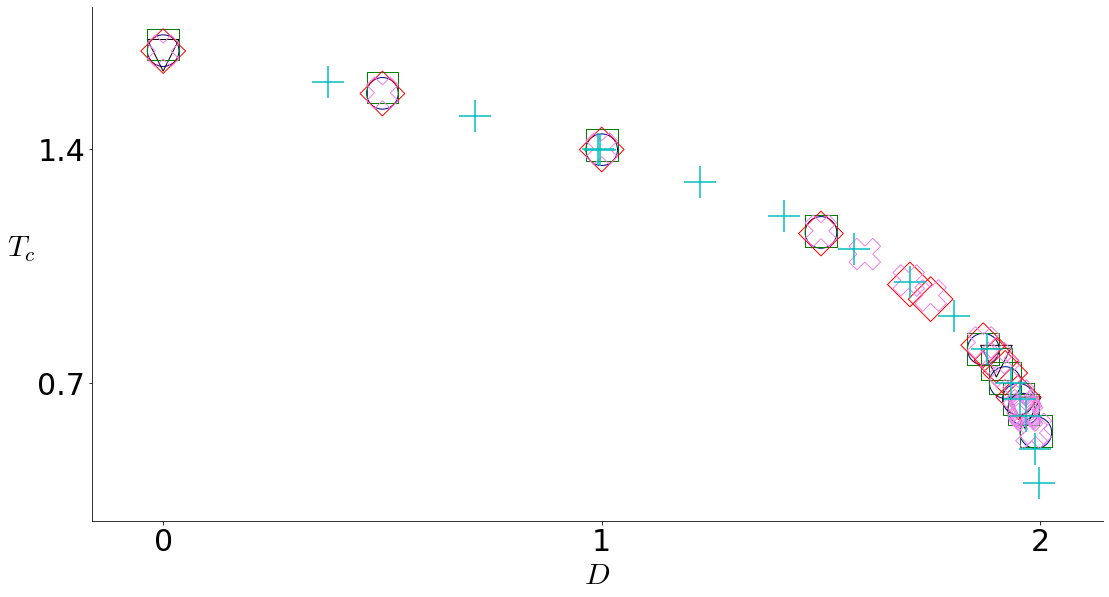

In [7]:
fig, ax = plt.subplots()
fig.set_size_inches(16, 9)

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams.update({'font.size': 30})

ax.yaxis.set_label_coords(-0.07, 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.7))

#plt.plot(T, M)
#ax.plot(D, [x[0] for x in Crit], label='MF II')
#ax.plot(D2, [x[0] for x in Crit2], '--', label='MF I')

radius=1000
plt.scatter([D for D, T in dBeale.items()], [T for D, T in dBeale.items()], label='Beale86',
         facecolors='none', edgecolors='darkblue', s=radius, marker='o')
plt.scatter([D for D, T in dXALP98.items()], [T for D, T in dXALP98.items()], label='XALP98',
         facecolors='none', edgecolors='black', s=radius, marker='v')
plt.scatter([D for D, T in dWLSCP06.items()], [T for D, T in dWLSCP06.items()], label='WL SCP06',
         facecolors='none', edgecolors='g', s=radius, marker='s')
plt.scatter([D for D, T in dButera.items()], [T for D, T in dButera.items()], label='Butera18',
         facecolors='none', edgecolors='r', s=radius, marker='D')
plt.scatter([D for D, T in dMR.items()], [T for D, T in dMR.items()], label='Machta-Rose',
         facecolors='none', edgecolors='violet', s=radius, marker='X')
plt.scatter([D for T, D in dZ17.items()], [T for T, D in dZ17.items()], label='Zierenberg-2017',
        color='c', s=radius, marker='+')

#markeredgecolor='black'

#ax.set_xlim([0.0, 2.0])
ax.set_ylabel("$T_{c}$", rotation=0, fontsize=30)
ax.set_xlabel("$D$", fontsize=30)

fig.tight_layout()

#plt.legend()
#plt.show()
plt.savefig('./images/MF_Phase_Diagram_3.png')
